# Decision Trees Part 1: Core Idea and Geometry

## Goal
A decision tree makes predictions by **splitting the feature space into rectangular regions** and assigning a single constant prediction to each region.
There are no weights and no distance metric. The model *is* the partition: a set of yes/no threshold questions that carve space into boxes.
Understanding the **geometry** of that partition explains nearly every strength and weakness of trees that comes later.

---

## What a Tree Does Geometrically
Each internal node asks one question of the form:

$$
x_j \le t \quad ?
$$

A single feature $x_j$ compared to a single threshold $t$. That question is a single **axis-aligned cut** through space — a vertical line if it splits on $x_1$, a horizontal line if it splits on $x_2$.

Stacking these cuts recursively partitions the feature space into $M$ non-overlapping **axis-aligned boxes** $R_1, \dots, R_M$ (the leaves):

$$
R_m = \{\, x : a_j \le x_j < b_j \text{ for each feature } j \,\}
$$

Every box is just an intersection of "greater than / less than" conditions on individual features. No diagonals, no curves — only cuts parallel to the axes.

---

## Constant Within Each Box
Once space is partitioned, the prediction is **constant inside each region**:

$$
f(x) = \sum_{m=1}^{M} c_m \cdot \mathbb{1}\{x \in R_m\}
$$

- Classification: $c_m$ = the majority class in box $m$.
- Regression: $c_m$ = the mean target in box $m$.

So a regression tree's prediction surface is literally a **step function** — flat inside each box, jumping at the boundaries. This is the single most important picture to hold in your head.

---

## Contrast: Logistic Regression (smooth, oblique boundary)
Logistic regression separates classes with a single hyperplane:

$$
\{\, x : w^\top x + b = 0 \,\}
$$

That boundary is **smooth and can be diagonal** — it mixes features through the weights $w$. A tree can never produce a true diagonal; it can only *approximate* one with a staircase of axis-aligned steps.

```text
logistic regression -> one straight (oblique) line
decision tree       -> a staircase of horizontal/vertical cuts
```

---

## Contrast: KNN (distance-based regions)
KNN's regions come from **distance** to training points (a Voronoi-like tessellation). Two consequences you already saw:

- The boundary curves and bends with the data.
- **Feature scaling matters** — bad scaling distorts the distances and the regions.

Trees are the opposite on that last point. A split is just a threshold on one raw feature, so any **monotonic rescaling of a feature only rescales the threshold** — the partition is unchanged.

```text
KNN            -> needs standardization (distance-based)
decision tree  -> scale-invariant per feature (threshold-based)
```

---

## Main Idea
A decision tree is a **piecewise-constant function over axis-aligned boxes**.

```text
recursive threshold cuts -> axis-aligned boxes -> constant prediction per box
```

- Logistic regression gives a smooth, possibly diagonal boundary.
- KNN gives distance-based regions sensitive to scaling.
- A tree gives blocky, scale-invariant boxes — flexible, but everything it does is built from horizontal and vertical cuts.

# Same feature space, three different geometries 

In [284]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier 

### A 2D Dataset whose classes are NOT linearly separable (two interleaving moons)


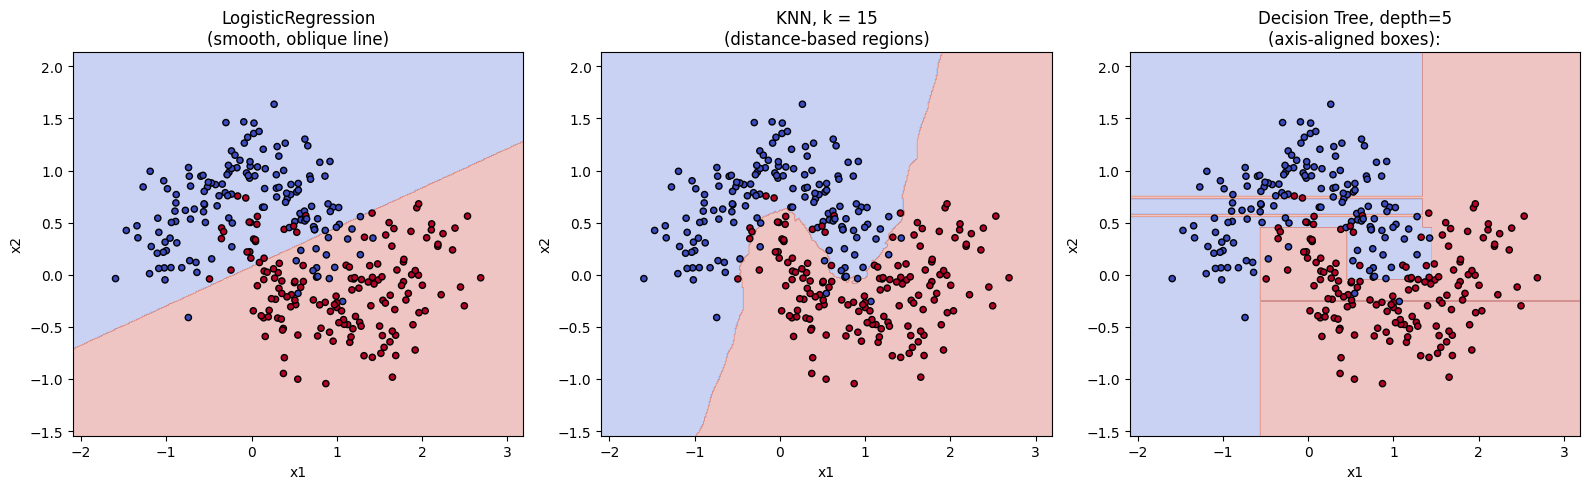

In [285]:
X, y = make_moons(n_samples= 300, noise = 0.25, random_state= 42)


# three models that partition the same space in three characteristic ways
models = {
    'LogisticRegression\n(smooth, oblique line)':       LogisticRegression(), 
    "KNN, k = 15\n(distance-based regions)":            KNeighborsClassifier(n_neighbors=15), 
    "Decision Tree, depth=5\n(axis-aligned boxes):":    DecisionTreeClassifier(max_depth = 5, random_state= 5),        
}

# build a find grid over the feature space so we can color every point by its prediction
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, model) in zip(axes, models.items()):
    model.fit(X, y)
    Z = model.predict(grid).reshape(xx.shape)          # predict the whole grid
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")  # colored decision regions
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=20)
    ax.set_title(name)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

## Constant within each box, 1D regression tree is a step function and adding depth just add steps:

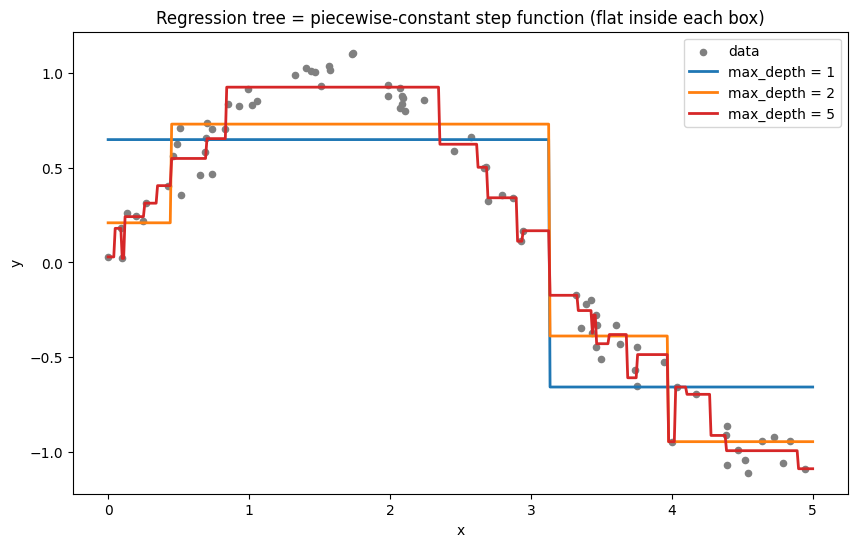

In [286]:
from sklearn.tree import DecisionTreeRegressor

# One feature, a smooth underlying signal (sine) plus noise
rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis = 0)
y = np.sin(X).ravel() + rng.normal(0, 0.1, size=X.shape[0])

X_grid = np.linspace(0, 5, 500).reshape(-1, 1)

plt.figure(figsize=(10,6))
plt.scatter(X, y, s = 20, c = "gray", label = "data")

# increasing max_depth splits the x-axis into MORE boxes
# inside each box the tree predicts ONE constant value (the mean target) -> flat segment 
for depth, color in [(1, "C0"), (2, "C1"), (5, "C3")]:
    tree = DecisionTreeRegressor(max_depth=depth).fit(X, y)
    plt.plot(X_grid, tree.predict(X_grid), color = color, lw = 2, label = f"max_depth = {depth}")
plt.title("Regression tree = piecewise-constant step function (flat inside each box)")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

# depth=1 -> 2 boxes -> 2 levels. depth=5 -> up to 32 boxes -> a fine staircase
# chasing the sine curve. The prediction NEVER slopes; it only jumps at split points.

## Connect the geometry to the splits, each box you see on the left is exactly one path of yes/no cuts in the tree on the right (this previous the "how splits are chosen")

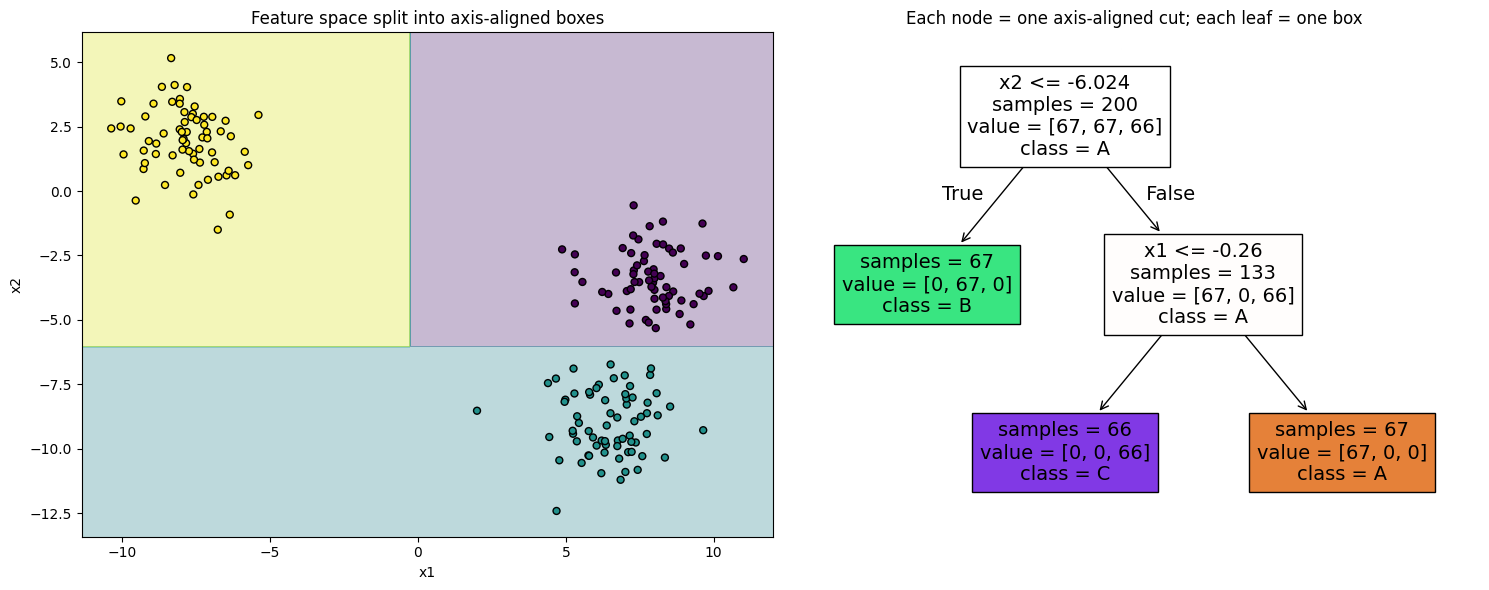

In [287]:
from sklearn.datasets import make_blobs
from sklearn.tree import DecisionTreeClassifier, plot_tree

X, y = make_blobs(n_samples=200, centers = 3, cluster_std=1.2, random_state=6)
tree = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X,y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: the partition: solid colored rectangles, each one axis-aligned box
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax1.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k", s=25)
ax1.set_title("Feature space split into axis-aligned boxes")
ax1.set_xlabel("x1"); ax1.set_ylabel("x2")

# RIGHT: the same tree as a diagram. Each node "xK <= t" is one cut from the left plot.
plot_tree(tree, ax=ax2, filled=True,
          feature_names=["x1", "x2"], class_names=["A", "B", "C"], impurity=False)
ax2.set_title("Each node = one axis-aligned cut; each leaf = one box")

plt.tight_layout()
plt.show()


# Decision Trees Part 2: The Two Flavors

## Goal
The exact same tree-growing procedure solves **two different problems**: classification and regression.
The recursive partitioning into axis-aligned boxes (Part 1) is *identical*. Only two things change:
1. **What the leaf outputs** (a class vs a number).
2. **The split criterion** used to decide where to cut.
Knowing precisely what a leaf stores is what lets you read, debug, and trust a tree's predictions.

---

## Classification Trees — leaf stores a class distribution
For a leaf (box) $R_m$, define the proportion of training points of class $k$ that landed there:

$$
p_{mk} = \frac{1}{N_m} \sum_{i \in R_m} \mathbb{1}\{y_i = k\}
$$

- $N_m$ = number of training points in the box.
- The vector $(p_{m1}, p_{m2}, \dots)$ is the **class distribution** — this is what `predict_proba` returns.
- The hard prediction is just the **majority class**:

$$
\hat{y}_m = \arg\max_k \; p_{mk}
$$

So a classification leaf doesn't store one label — it stores the *counts* of each class, and reports the most common one.

---

## Regression Trees — leaf stores a mean
For a leaf $R_m$, the prediction is the **average target** of the training points in that box:

$$
c_m = \frac{1}{N_m} \sum_{i \in R_m} y_i
$$

That's the value that minimizes squared error within the box, which is exactly why squared-error splitting and a mean-valued leaf go together. Combined with Part 1, this is why a regression tree is a **piecewise-constant step function**: each step's height is the mean of its box.

---

## Same Algorithm, Different Split Criterion
Both flavors do **greedy recursive binary splitting** — scan features and thresholds, pick the cut that most "purifies" the children. The only difference is the measure of purity:

```text

## Classification leaf = class distribution, prediction = majority class


In [288]:
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True) # 3 classes
clf = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X, y)

# .apply tells us WHICH leaf each training sample falls into
leaf_id = clf.apply(X)

# For each leaf, compute the class distribution manually from the training labels 
print("Manual class distribution per leaf: ")
for leaf in np.unique(leaf_id):
    members = y[leaf_id == leaf]
    counts = np.bincount(members, minlength=3)
    dist = counts / counts.sum()
    
    print(f"    leaf {leaf}: counts = {counts}, distribution = {np.round(dist, 3)},  majority class = {counts.argmax()}")
    

Manual class distribution per leaf: 
    leaf 1: counts = [50  0  0], distribution = [1. 0. 0.],  majority class = 0
    leaf 3: counts = [ 0 49  5], distribution = [0.    0.907 0.093],  majority class = 1
    leaf 4: counts = [ 0  1 45], distribution = [0.    0.022 0.978],  majority class = 2


### Now verify the tree REPORTS that same distribution. Pick a sample, see its leaf, and confirm predict_proba == leaf's class proportions, predict == majority. 

In [289]:
i = 100
leaf = clf.apply(X[[i]])[0]
manual_dist = np.bincount(y[leaf_id == leaf], minlength= 3)
manual_dist = manual_dist / manual_dist.sum()
print(f"\nSample {i} lands in leaf {leaf}")
print("  predict_proba :", np.round(clf.predict_proba(X[[i]])[0], 3))
print("  manual dist   :", np.round(manual_dist, 3))     # <-- identical
print("  predict (class):", clf.predict(X[[i]])[0])      # <-- the argmax


Sample 100 lands in leaf 4
  predict_proba : [0.    0.022 0.978]
  manual dist   : [0.    0.022 0.978]
  predict (class): 2


## Regression leaf stores the mean of the targets, and that's literally what gets predicted

In [290]:
from sklearn.datasets import load_diabetes

X, y  = load_diabetes(return_X_y=True)
reg = DecisionTreeRegressor(max_depth=2, random_state=0).fit(X, y)

leaf_id = reg.apply(X)

# Each leaf's prediction should equal the average target of its training members
print("Per-leaf mean target vs tree's stored leaf value:")
for leaf in np.unique(leaf_id):
    members = y[leaf_id == leaf]
    manual_mean = members.mean()
    # the tree stores its leaf values in tree_.value, indexed by node id
    stored_value = reg.tree_.value[leaf].ravel()[0]
    print(f"  leaf {leaf}: n={len(members):3d}, manual mean={manual_mean:8.2f}, "
          f"tree value={stored_value:8.2f}")

# And confirm a prediction is just the mean of the box the sample falls into
i = 0
leaf = reg.apply(X[[i]])[0]
print(f"\nSample {i} lands in leaf {leaf}")
print("  tree prediction       :", round(reg.predict(X[[i]])[0], 2))
print("  mean of targets in leaf:", round(y[leaf_id == leaf].mean(), 2))   # <-- identical

Per-leaf mean target vs tree's stored leaf value:
  leaf 2: n=171, manual mean=   96.31, tree value=   96.31
  leaf 3: n= 47, manual mean=  159.74, tree value=  159.74
  leaf 5: n=116, manual mean=  162.68, tree value=  162.68
  leaf 6: n=108, manual mean=  225.88, tree value=  225.88

Sample 0 lands in leaf 6
  tree prediction       : 225.88
  mean of targets in leaf: 225.88


## Same algorithm where the leaf output and split criterion are what differ

In [291]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=400, n_features=4, n_informative=3, n_redundant= 0, random_state=0)

clg = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X, y)
reg = DecisionTreeRegressor(max_depth=3, random_state=0).fit(X, y.astype(float)) # squared error
print("classifier split criterion:", clf.criterion)        # gini
print("regressor  split criterion:", reg.criterion)         # squared_error


classifier split criterion: gini
regressor  split criterion: squared_error


In [292]:
# BRIDGE: for a 0/1 target, "mean of targets in a leaf" == "fraction positive" == P(class=1)
leaf_id = clf.apply(X)
i = 7
leaf = clf.apply(X[[i]])[0]
print(f"\nSample {i}, leaf {leaf}:")
print("  P(class=1) from classifier proba :", round(clf.predict_proba(X[[i]])[0, 1], 3))
print("  mean of 0/1 target in that leaf  :", round(y[leaf_id == leaf].mean(), 3))  # same number

# DIFFERENT CRITERION -> can pick different cuts. Compare the ROOT split each flavor chose:
print("\nRoot split chosen by each flavor (same data, different criterion):")
print("  classifier: feature", clf.tree_.feature[0], "<=", round(clf.tree_.threshold[0], 3))
print("  regressor : feature", reg.tree_.feature[0], "<=", round(reg.tree_.threshold[0], 3))


Sample 7, leaf 4:
  P(class=1) from classifier proba : 0.022
  mean of 0/1 target in that leaf  : 0.554

Root split chosen by each flavor (same data, different criterion):
  classifier: feature 3 <= 0.8
  regressor : feature 3 <= -0.433


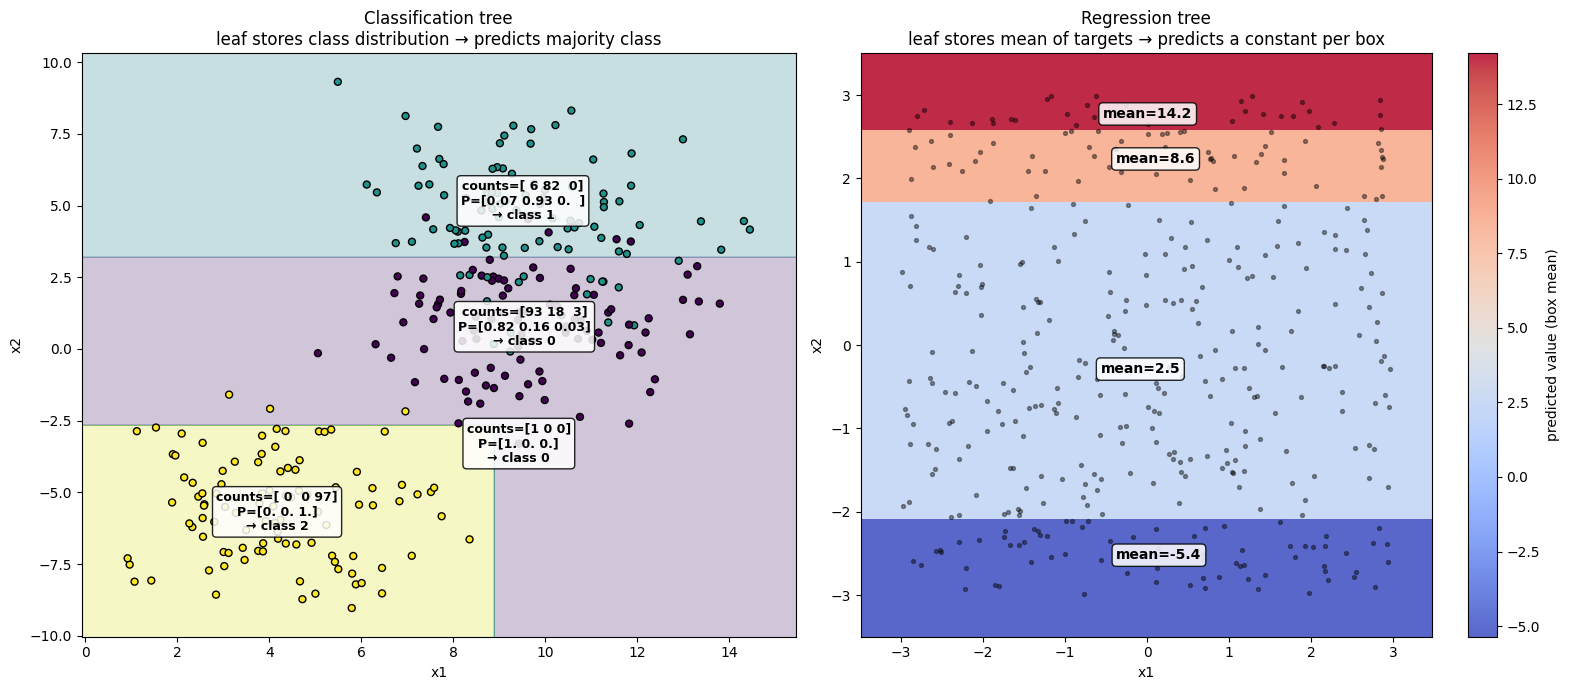

In [293]:
# Demonstration: visualizing what each flavor's leaf stores
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# LEFT: CLASSIFICATION — each box is colored by its MAJORITY CLASS,
#       and annotated with the full CLASS DISTRIBUTION (what predict_proba returns)
Xc, yc = make_blobs(n_samples=300, centers=3, cluster_std=1.8, random_state=4)
clf = DecisionTreeClassifier(max_depth=2, random_state=0).fit(Xc, yc)

# Grid over the space, predict the majority class everywhere -> colored regions
x_min, x_max = Xc[:, 0].min() - 1, Xc[:, 0].max() + 1
y_min, y_max = Xc[:, 1].min() - 1, Xc[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax1.contourf(xx, yy, Z, alpha=0.25, cmap="viridis")
ax1.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="viridis", edgecolor="k", s=25)

# Annotate each leaf with the class counts/distribution it stores
leaf_id = clf.apply(Xc)
for leaf in np.unique(leaf_id):
    mask = leaf_id == leaf
    cx, cy = Xc[mask, 0].mean(), Xc[mask, 1].mean()        # centroid sits inside the box
    counts = np.bincount(yc[mask], minlength=3)
    dist = counts / counts.sum()
    ax1.text(cx, cy, f"counts={counts}\nP={np.round(dist,2)}\n→ class {counts.argmax()}",
             ha="center", va="center", fontsize=9, weight="bold",
             bbox=dict(boxstyle="round", fc="white", ec="black", alpha=0.85))

ax1.set_title("Classification tree\nleaf stores class distribution → predicts majority class")
ax1.set_xlabel("x1"); ax1.set_ylabel("x2")


# RIGHT: REGRESSION — each box is shaded by its MEAN TARGET (continuous colormap),
#        i.e. the piecewise-constant prediction SURFACE, annotated with that mean
rng = np.random.RandomState(0)
Xr = rng.uniform(-3, 3, size=(400, 2))
yr = Xr[:, 0]**2 + 0.5 * Xr[:, 1]**3 + rng.normal(0, 1, size=400)   # smooth-ish target
reg = DecisionTreeRegressor(max_depth=2, random_state=0).fit(Xr, yr)

x_min, x_max = Xr[:, 0].min() - 0.5, Xr[:, 0].max() + 0.5
y_min, y_max = Xr[:, 1].min() - 0.5, Xr[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
Zr = reg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# pcolormesh shows the BLOCKY piecewise-constant surface crisply — flat color per box
mesh = ax2.pcolormesh(xx, yy, Zr, cmap="coolwarm", shading="auto", alpha=0.85)
ax2.scatter(Xr[:, 0], Xr[:, 1], c="k", s=8, alpha=0.4)
fig.colorbar(mesh, ax=ax2, label="predicted value (box mean)")

# Annotate each leaf with the MEAN target it stores
leaf_id = reg.apply(Xr)
for leaf in np.unique(leaf_id):
    mask = leaf_id == leaf
    cx, cy = Xr[mask, 0].mean(), Xr[mask, 1].mean()
    mean_val = yr[mask].mean()
    ax2.text(cx, cy, f"mean={mean_val:.1f}", ha="center", va="center",
             fontsize=10, weight="bold",
             bbox=dict(boxstyle="round", fc="white", ec="black", alpha=0.85))

ax2.set_title("Regression tree\nleaf stores mean of targets → predicts a constant per box")
ax2.set_xlabel("x1"); ax2.set_ylabel("x2")

plt.tight_layout()
plt.show()

# Same axis-aligned boxes on both sides (identical algorithm, depth=2).
# Only the READ-OUT differs: left labels each box with its class distribution/majority,
# right shades each box by its mean target. That is the entire "two flavors" distinction.

# Decision Trees Part 3: How a Split Is Chosen

## Goal
Parts 1–2 told us *what* a tree is (axis-aligned boxes) and *what a leaf reports* (class distribution or mean).
This part is the engine: **how the tree decides where to cut.**
Every split is chosen by the same greedy rule — try everything, score each candidate by how much it reduces *impurity*, keep the winner. Understanding the scoring function explains why trees grow the way they do.

---

## Greedy, Top-Down, Recursive, Binary
Four words that define the procedure:

- **Top-down**: start with all data at the root, split downward.
- **Binary**: every split is one feature vs one threshold → exactly two children.
- **Greedy**: pick the *locally* best split right now; never look ahead or backtrack.
- **Recursive**: repeat the same procedure independently on each child.

At a node, the search is brute force:

```python
for each feature j:
    for each candidate threshold t:
        split into  left = {x_j <= t},  right = {x_j > t}
        score the split by impurity reduction
keep the (feature, threshold) with the best score
```

Candidate thresholds are the **midpoints between consecutive sorted values** of a feature — those are the only places the split actually changes which points go left vs right.

---

## Impurity Decrease — the scoring function
A split is scored by how much "mixed-up-ness" it removes. For a parent node split into left/right children:

$$
\Delta I = I(\text{parent}) - \left( \frac{N_L}{N}\,I(\text{left}) + \frac{N_R}{N}\,I(\text{right}) \right)
$$

The second term is the **weighted average impurity of the children** (weighted by how many points fall in each). We want $\Delta I$ as large as possible — children that are purer than the parent. We just need a function $I(\cdot)$ that measures impurity.

---

## Classification Impurity: Gini and Entropy
Let $p_k$ be the fraction of class $k$ in a node.

**Gini impurity** — probability of misclassifying a random point if labeled by the node's class distribution:

$$
G = \sum_k p_k(1 - p_k) = 1 - \sum_k p_k^2
$$

**Entropy** — bits of "surprise" in the label distribution; the decrease in entropy is called **information gain**:

$$
H = -\sum_k p_k \log_2 p_k
$$

Both are **0 when the node is pure** (one class) and **maximal when classes are evenly mixed**. Gini is slightly cheaper (no log) and is sklearn's default; entropy/information gain comes from C4.5. In practice they almost always pick similar splits.

---

## Regression Impurity: Variance / SSE
There are no classes to count, so impurity is the **spread of the target** in the node — its variance, or equivalently the sum of squared errors around the node mean $\bar{y}_m$:

$$
\text{SSE}_m = \sum_{i \in R_m}(y_i - \bar{y}_m)^2 \qquad\Longleftrightarrow\qquad \text{Var}_m = \frac{1}{N_m}\text{SSE}_m
$$

A split is scored by how much it **reduces total SSE** — the regression analogue of $\Delta I$. Minimizing SSE is exactly why the leaf stores the mean (Part 2): the mean is the constant that minimizes squared error.

---

## Why NOT Plain Misclassification Error? (the key insight)
The obvious impurity for classification is **misclassification error**:

$$
E = 1 - \max_k p_k
$$

It seems natural, but it's a **bad tree-growing criterion** because it's *piecewise-linear in $p_k$* and only cares about the majority class. It's blind to improvements that don't flip the majority. Concretely:

- It can score two very different splits **identically**, even when one produces a **pure child node** and the other doesn't.
- Gini and entropy are **strictly concave**, so they reward making *any* node more skewed — even when the majority label doesn't change. That sensitivity lets them prefer the split that carves out a pure region.

```text
misclassification error -> only notices when the majority class flips (blunt)
Gini / entropy          -> notice ANY shift in class proportions (sensitive)
```

This is *the* reason trees grow with Gini/entropy and only sometimes use error for *pruning*. The next cell demonstrates it numerically.

---

## Main Idea
A split is chosen by **brute-force search scored by impurity reduction**.

```text
scan every feature × threshold -> score by ΔI (impurity decrease) -> keep the best -> recurse
```

- Classification impurity: Gini or entropy (information gain).
- Regression impurity: variance / SSE reduction.
- Gini/entropy beat misclassification error for *growing* because their concavity makes them sensitive to class-proportion changes that error ignores.

## Plots three impurity measures so you can see the concavity that the notes hinge on:

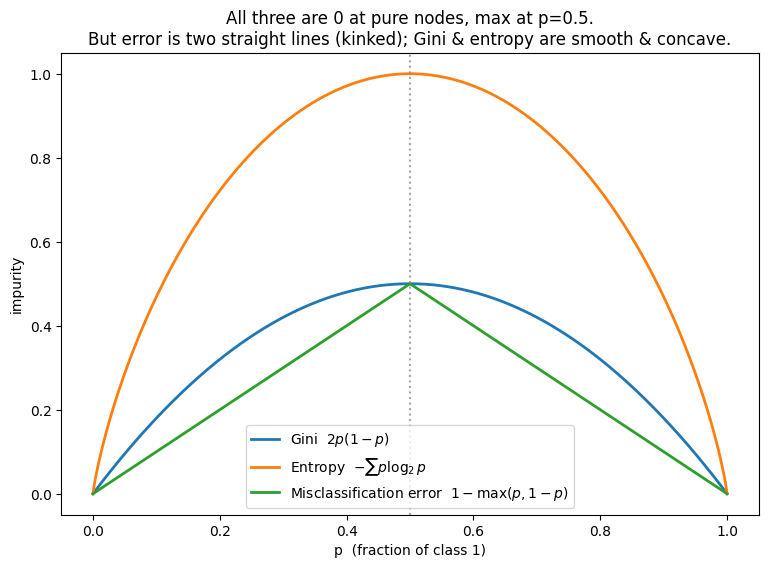

In [294]:
# Cell 1 — The shape of impurity: why concavity matters
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0, 1, 500)          # fraction of class 1 in a binary node

gini    = 2 * p * (1 - p)                                  # 1 - (p^2 + (1-p)^2) = 2p(1-p)
entropy = -(p * np.log2(p + 1e-12) + (1-p) * np.log2(1-p + 1e-12))
error   = 1 - np.maximum(p, 1 - p)                         # 1 - max(p, 1-p)

plt.figure(figsize=(9, 6))
plt.plot(p, gini,    lw=2, label="Gini  $2p(1-p)$")
plt.plot(p, entropy, lw=2, label="Entropy  $-\\sum p\\log_2 p$")
plt.plot(p, error,   lw=2, label="Misclassification error  $1-\\max(p,1-p)$")
plt.axvline(0.5, color="gray", ls=":", alpha=0.7)
plt.xlabel("p  (fraction of class 1)"); plt.ylabel("impurity")
plt.title("All three are 0 at pure nodes, max at p=0.5.\n"
          "But error is two straight lines (kinked); Gini & entropy are smooth & concave.")
plt.legend(); plt.show()

# The CONCAVITY (curvature) of Gini/entropy is the whole point: a concave impurity
# always rewards splitting a node into more-skewed children. The piecewise-LINEAR error
# is flat along each segment, so many splits look equally good to it.

## Build Greedy Split search from scratch and visualizes the gain over every can    didate threshold.

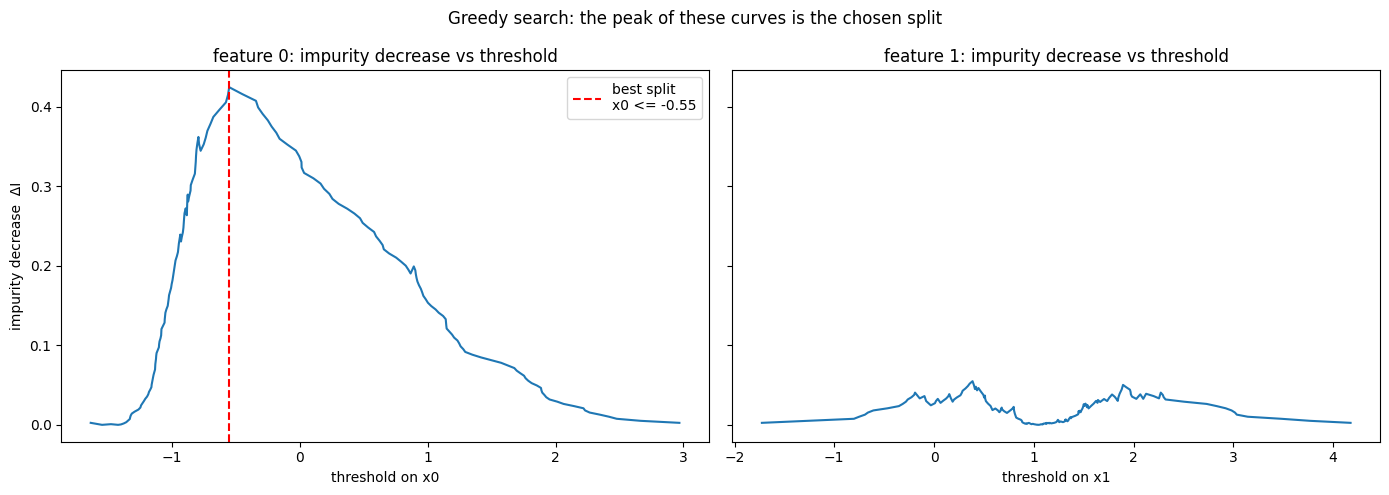

From scratch: split on feature 0 at -0.5493 (gain=0.4247)
sklearn root: feature 0 at -0.5493


In [295]:
# Cell 2 — Build the greedy best-split search from scratch, and watch it scan
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier

X, y = make_classification(n_samples=200, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=3)

def gini(y):
    if len(y) == 0:
        return 0.0
    p = np.bincount(y) / len(y)
    return 1 - np.sum(p**2)

def split_score(X, y, feature, threshold):
    """Weighted child impurity for one candidate split (lower = better)."""
    left  = y[X[:, feature] <= threshold]
    right = y[X[:, feature] >  threshold]
    n = len(y)
    return len(left)/n * gini(left) + len(right)/n * gini(right)

# Scan EVERY feature and EVERY midpoint threshold, recording impurity decrease
parent_imp = gini(y)
fig, axes = plt.subplots(1, X.shape[1], figsize=(14, 5), sharey=True)
best = {"gain": -np.inf}

for j in range(X.shape[1]):
    vals = np.unique(X[:, j])
    thresholds = (vals[:-1] + vals[1:]) / 2          # midpoints = the only useful cuts
    gains = []
    for t in thresholds:
        gain = parent_imp - split_score(X, y, j, t)  # ΔI = parent - weighted children
        gains.append(gain)
        if gain > best["gain"]:
            best = {"gain": gain, "feature": j, "threshold": t}
    axes[j].plot(thresholds, gains)
    axes[j].set_title(f"feature {j}: impurity decrease vs threshold")
    axes[j].set_xlabel(f"threshold on x{j}")
axes[0].set_ylabel("impurity decrease  ΔI")

# Mark the global winner across both features
axes[best["feature"]].axvline(best["threshold"], color="red", ls="--",
                              label=f"best split\nx{best['feature']} <= {best['threshold']:.2f}")
axes[best["feature"]].legend()
plt.suptitle("Greedy search: the peak of these curves is the chosen split")
plt.tight_layout(); plt.show()

print(f"From scratch: split on feature {best['feature']} at {best['threshold']:.4f} "
      f"(gain={best['gain']:.4f})")

# Verify against sklearn's ROOT split — it does the exact same search
sk = DecisionTreeClassifier(max_depth=1, criterion="gini", random_state=0).fit(X, y)
print(f"sklearn root: feature {sk.tree_.feature[0]} at {sk.tree_.threshold[0]:.4f}")

## Regression version, same scan, but scored by SSE reduction:

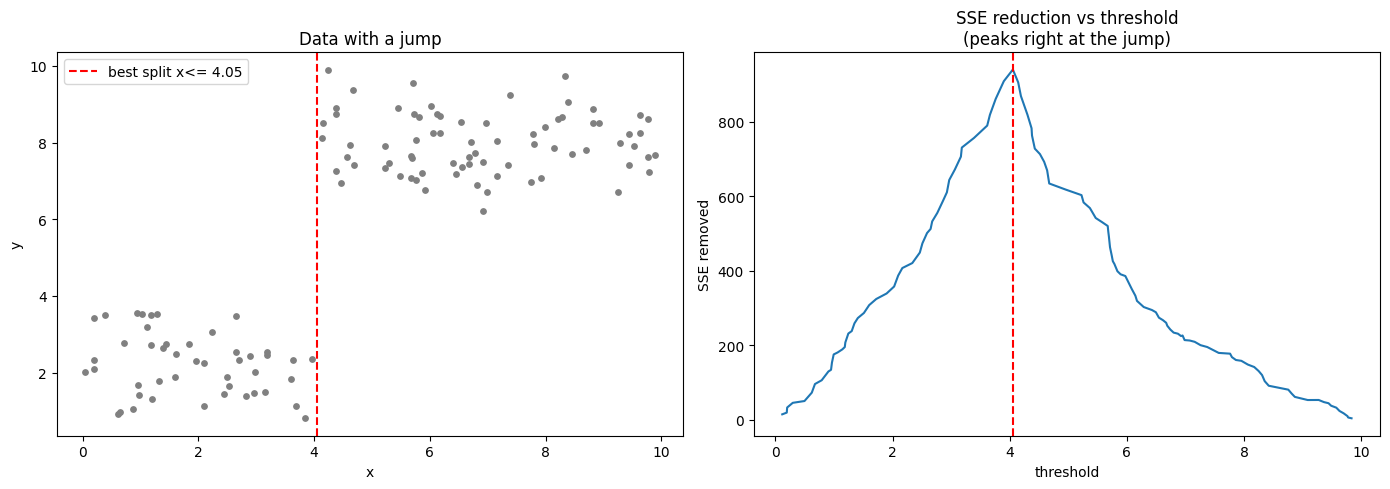

from scratch: 4.054   |   sklearn: 4.054


In [296]:
# Cell 3 — Regression: the same greedy scan, scored by SSE (variance) reduction
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

rng = np.random.RandomState(0)
X = np.sort(rng.uniform(0, 10, 120)).reshape(-1, 1)
y = np.where(X.ravel() < 4, 2.0, 8.0) + rng.normal(0, 0.8, 120)   # a clear jump at x=4

def sse(y):
    return np.sum((y - y.mean())**2) if len(y) else 0.0           # spread around the mean

parent_sse = sse(y)
vals = np.unique(X.ravel())
thresholds = (vals[:-1] + vals[1:]) / 2

reductions = []
for t in thresholds:
    left, right = y[X.ravel() <= t], y[X.ravel() > t]
    reductions.append(parent_sse - (sse(left) + sse(right)))      # total SSE removed

best_t = thresholds[np.argmax(reductions)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.scatter(X, y, s=15, c="gray"); ax1.axvline(best_t, color="red", ls="--",
            label=f"best split x<= {best_t:.2f}")
ax1.set_title("Data with a jump"); ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.legend()

ax2.plot(thresholds, reductions); ax2.axvline(best_t, color="red", ls="--")
ax2.set_title("SSE reduction vs threshold\n(peaks right at the jump)")
ax2.set_xlabel("threshold"); ax2.set_ylabel("SSE removed")
plt.tight_layout(); plt.show()

# The split that removes the most variance lands exactly on the structural break in y.
sk = DecisionTreeRegressor(max_depth=1).fit(X, y)
print(f"from scratch: {best_t:.3f}   |   sklearn: {sk.tree_.threshold[0]:.3f}")

## Payoff, the canonical demonstration that misclassification error ties two splits while Gini and entropy correctly prefer the one that produces a pure node:  

criterion     parent   Split A   Split B  prefers
error          0.500     0.250     0.250    TIE!
gini           0.500     0.375     0.333    Split B ✓
entropy        1.000     0.811     0.689    Split B ✓


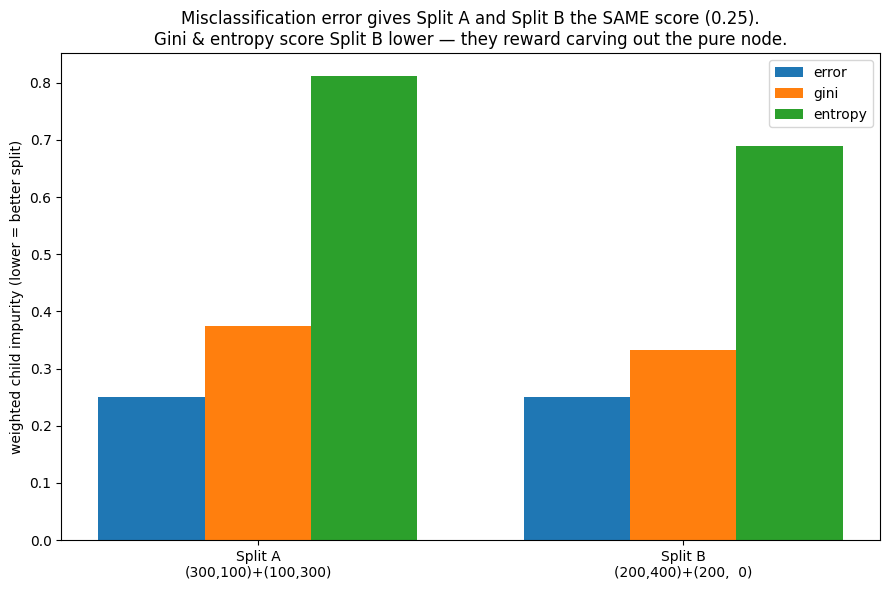

In [297]:
# Cell 4 — WHY NOT misclassification error: error ties, Gini/entropy break the tie
import numpy as np
import matplotlib.pyplot as plt

# Parent: 800 points, 400 class-0 and 400 class-1  (50/50, maximally impure)
# Two candidate splits of that same parent:
#   Split A: children (300,100) and (100,300)        -> neither child is pure
#   Split B: children (200,400) and (200,  0)        -> the second child is PURE
splits = {
    "Split A\n(300,100)+(100,300)": [(300, 100), (100, 300)],
    "Split B\n(200,400)+(200,  0)": [(200, 400), (200,   0)],
}

def gini(c):    p = np.array(c)/sum(c); return 1 - np.sum(p**2)
def entropy(c): p = np.array(c)/sum(c); p = p[p>0]; return -np.sum(p*np.log2(p))
def error(c):   p = np.array(c)/sum(c); return 1 - p.max()

def weighted(children, fn):
    total = sum(sum(c) for c in children)
    return sum(sum(c)/total * fn(c) for c in children)

parent = (400, 400)
print(f"{'criterion':<12}{'parent':>8}{'Split A':>10}{'Split B':>10}{'  prefers'}")
results = {}
for name, fn in [("error", error), ("gini", gini), ("entropy", entropy)]:
    pa = fn(parent)
    a  = weighted(splits["Split A\n(300,100)+(100,300)"], fn)
    b  = weighted(splits["Split B\n(200,400)+(200,  0)"], fn)
    pref = "TIE!" if abs(a-b) < 1e-9 else ("Split B ✓" if b < a else "Split A")
    results[name] = (a, b)
    print(f"{name:<12}{pa:>8.3f}{a:>10.3f}{b:>10.3f}    {pref}")

# Plot the weighted child impurity of each split, per criterion
labels = list(splits.keys())
x = np.arange(len(labels)); w = 0.25
plt.figure(figsize=(9, 6))
for i, crit in enumerate(["error", "gini", "entropy"]):
    plt.bar(x + (i-1)*w, results[crit], w, label=crit)
plt.xticks(x, labels); plt.ylabel("weighted child impurity (lower = better split)")
plt.title("Misclassification error gives Split A and Split B the SAME score (0.25).\n"
          "Gini & entropy score Split B lower — they reward carving out the pure node.")
plt.legend(); plt.tight_layout(); plt.show()

# Takeaway: error = 0.25 for BOTH splits, so it can't tell them apart — even though
# Split B isolates a 100%-pure node. Gini/entropy's concavity sees that purity and
# prefers Split B. That's exactly why trees GROW with Gini/entropy, not error.

# Decision Trees Part 4: Why a Fully Grown Tree Overfits

## Goal
Part 3 gave the tree a relentless engine: keep splitting to reduce impurity.
Left unchecked, that engine doesn't stop until **every leaf is pure** — one training point (or a few identical ones) per box.
A tree grown to purity has effectively **memorized the training set**. This part explains *why* that is overfitting in the precise language of **bias and variance**, and sets up everything in Part 5 (pruning) and the entire Ensembles track.

---

## A Tree Grown to Purity Is a Lookup Table
If a tree is allowed unlimited depth, the impurity-reduction search will keep cutting until each leaf contains a single class (or a single value). At that point:

- Training impurity is **0**.
- Training accuracy is **100%** (training error → 0).
- Each leaf is a tiny box drawn around individual training points.

That is not learning a pattern — it's building a **lookup table** of the training data. The boxes are shaped to fit noise, not signal.

---

## Low Bias, High Variance
This is the exact spot in the bias–variance decomposition where trees live. For a prediction, expected error decomposes as:

$$
\mathbb{E}\big[(y - \hat{f}(x))^2\big] = \underbrace{\text{Bias}^2}_{\text{wrong on avg}} + \underbrace{\text{Var}}_{\text{unstable}} + \underbrace{\sigma^2}_{\text{irreducible noise}}
$$

A fully grown tree sits at one extreme:

- **Low bias** — it's flexible enough to represent almost any function; on average it can fit the true signal. Its boxes can be arbitrarily fine, so it doesn't *systematically* under- or over-shoot.
- **High variance** — because the boxes are fit to individual points, **a small change in the training data produces a wildly different tree**. Re-draw the training set and the partition reshuffles.

```text
shallow tree -> few big boxes -> HIGH bias, LOW variance  (too rigid)
deep   tree -> many tiny boxes -> LOW bias, HIGH variance (too sensitive)
```

Depth is the **complexity knob** that slides the tree along the bias–variance trade-off.

---

## Why the Variance Is So High Specifically
Two structural reasons trees are *high-variance learners* in particular:

1. **Greedy + hierarchical**: a different split at the root sends different points down each branch, and *every* split below it changes too. One flipped decision near the top cascades. Errors compound down the tree.
2. **Hard thresholds on single points**: with tiny leaves, the threshold is often set by one or two boundary points. Move or remove them and the cut jumps.

This instability is not a bug to be fully fixed within a single tree — it's the defining property that **bagging and random forests exploit**: average many high-variance, low-bias trees and the variance shrinks while the low bias is preserved.

---

## The Train/Test Gap Is the Symptom
You diagnose overfitting by the **gap between training and validation performance**:

```text
training error keeps falling toward 0 as depth increases
validation error falls, bottoms out, then RISES again
the widening gap = variance taking over
```

The minimum of the validation curve is the sweet spot — the depth where added flexibility stops buying real signal and starts fitting noise. For your time-series work in TickerTracker, this gap is exactly what a **chronological** validation split is meant to expose honestly.

---

## Main Idea
A fully grown tree memorizes the training set: it draws a box around (almost) every point.

```text
grow to purity -> train error = 0 -> low bias, very high variance -> overfit
```

- Depth is the knob on the bias–variance trade-off.
- Trees are *especially* high-variance because greedy hierarchical splits cascade and tiny leaves hinge on individual points.
- That high variance is precisely what pruning (Part 5) controls and what ensembles (the next track) average away.

## Canonical overfitting curve, train accuracy marches to 100\% while validation peaks and falls, and the gap is the variance

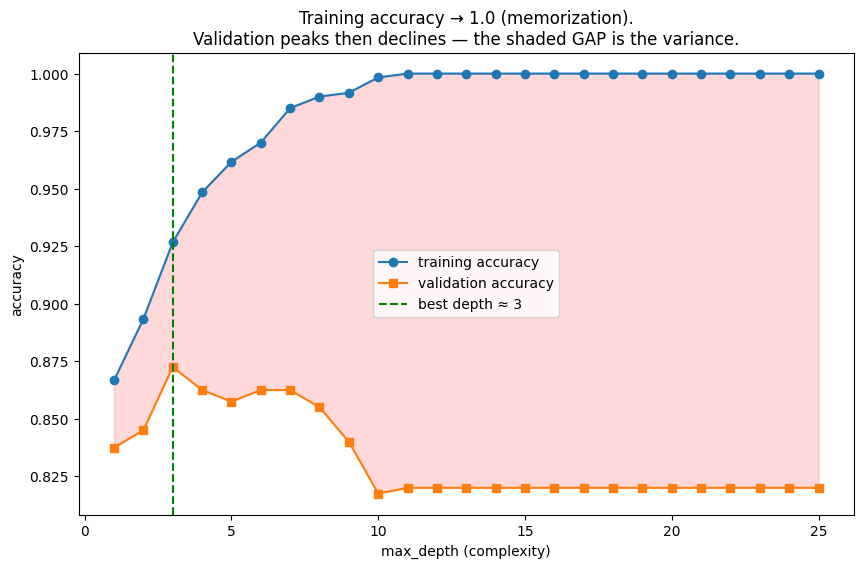

At max depth: train=1.000, test=0.820  -> gap = 0.180


In [298]:
# Cell 1 — The overfitting signature: train→100%, validation peaks then falls
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=1000, n_features=20, n_informative=5,
                           n_redundant=5, flip_y=0.10, random_state=0)  # flip_y adds noise
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.4, random_state=0)

depths = range(1, 26)
train_acc, test_acc = [], []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X_tr, y_tr)
    train_acc.append(clf.score(X_tr, y_tr))
    test_acc.append(clf.score(X_te, y_te))

best_d = depths[int(np.argmax(test_acc))]

plt.figure(figsize=(10, 6))
plt.plot(depths, train_acc, "o-", label="training accuracy")
plt.plot(depths, test_acc,  "s-", label="validation accuracy")
plt.axvline(best_d, color="green", ls="--", label=f"best depth ≈ {best_d}")
plt.fill_between(depths, test_acc, train_acc, alpha=0.15, color="red")
plt.xlabel("max_depth (complexity)"); plt.ylabel("accuracy")
plt.title("Training accuracy → 1.0 (memorization).\n"
          "Validation peaks then declines — the shaded GAP is the variance.")
plt.legend(); plt.show()

print(f"At max depth: train={train_acc[-1]:.3f}, test={test_acc[-1]:.3f}  "
      f"-> gap = {train_acc[-1]-test_acc[-1]:.3f}")
# A fully grown tree hits ~1.0 on train but generalizes worse than a shallower one.

## High variance literal,train deep vs shallow trees on resampled data and watch the deep boundary thrash while the shallow one stays put   


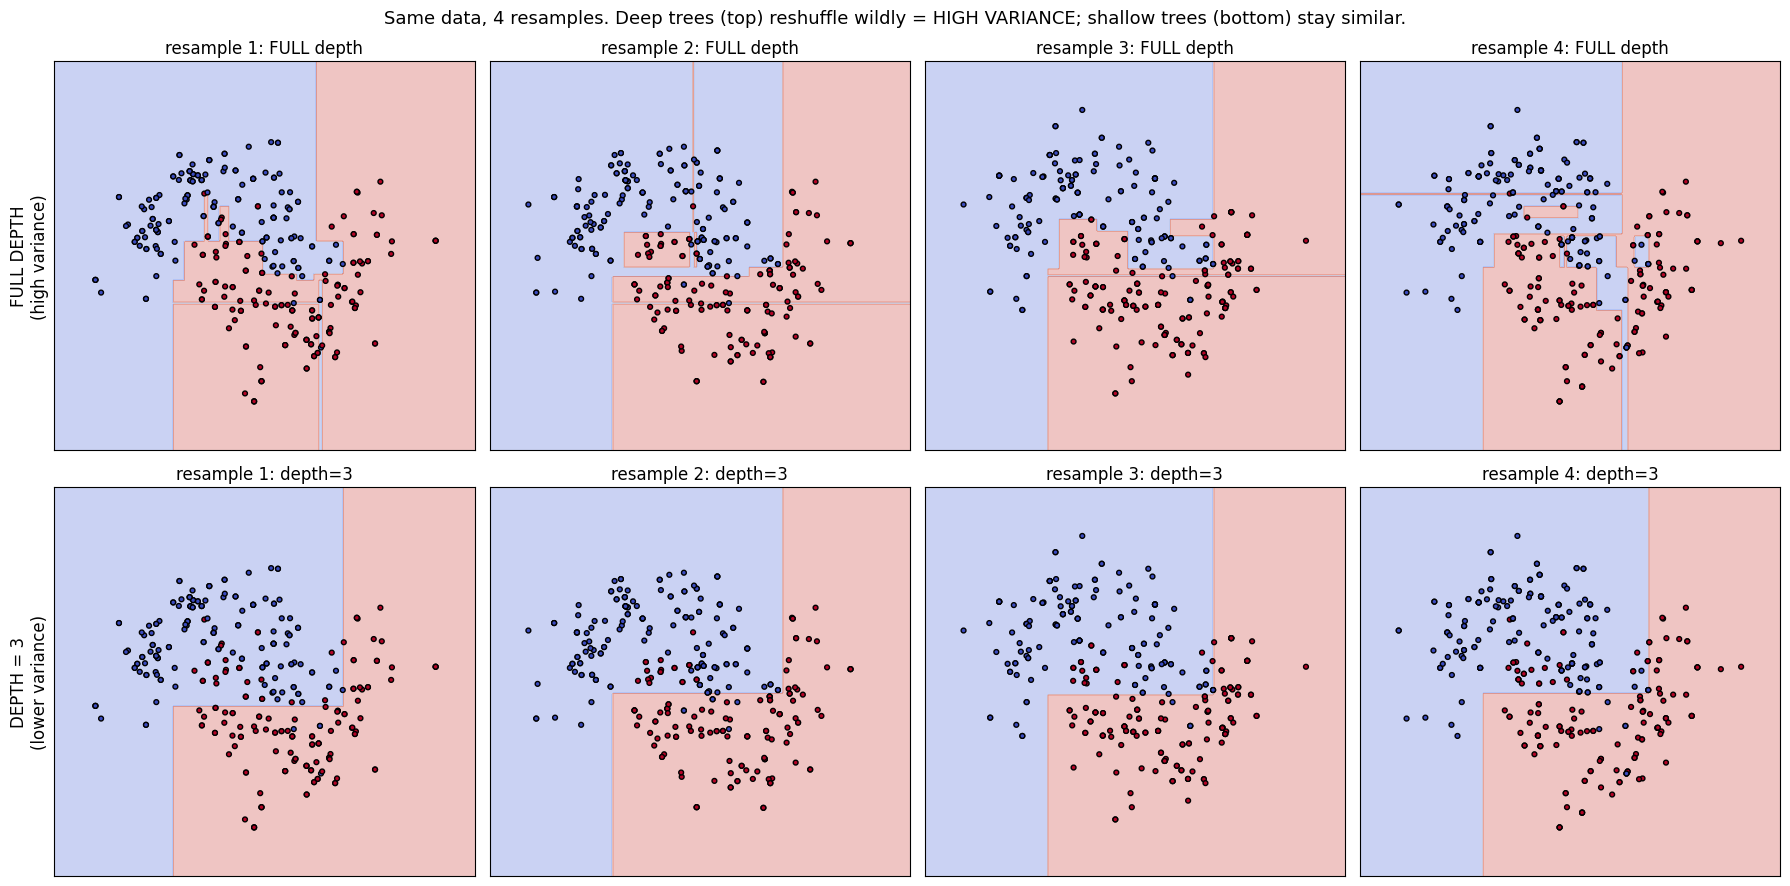

In [299]:
# Cell 2 — Visualizing variance: small data changes -> very different deep trees
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

X, y = make_moons(n_samples=300, noise=0.3, random_state=0)
x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
rng = np.random.RandomState(1)

for col in range(4):
    # Each column = a different bootstrap resample of the SAME dataset
    idx = rng.choice(len(X), len(X), replace=True)
    Xb, yb = X[idx], y[idx]

    # TOP row: fully grown (deep) tree — boundary changes a LOT across resamples
    deep = DecisionTreeClassifier(random_state=0).fit(Xb, yb)
    Zd = deep.predict(grid).reshape(xx.shape)
    axes[0, col].contourf(xx, yy, Zd, alpha=0.3, cmap="coolwarm")
    axes[0, col].scatter(Xb[:,0], Xb[:,1], c=yb, cmap="coolwarm", edgecolor="k", s=12)
    axes[0, col].set_title(f"resample {col+1}: FULL depth")
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

    # BOTTOM row: shallow tree — boundary is far more STABLE across the same resamples
    shallow = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xb, yb)
    Zs = shallow.predict(grid).reshape(xx.shape)
    axes[1, col].contourf(xx, yy, Zs, alpha=0.3, cmap="coolwarm")
    axes[1, col].scatter(Xb[:,0], Xb[:,1], c=yb, cmap="coolwarm", edgecolor="k", s=12)
    axes[1, col].set_title(f"resample {col+1}: depth=3")
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

axes[0,0].set_ylabel("FULL DEPTH\n(high variance)", fontsize=12)
axes[1,0].set_ylabel("DEPTH = 3\n(lower variance)", fontsize=12)
plt.suptitle("Same data, 4 resamples. Deep trees (top) reshuffle wildly = HIGH VARIANCE; "
             "shallow trees (bottom) stay similar.", fontsize=13)
plt.tight_layout(); plt.show()

## Ties it back to the formal bias-variance picture - an empirical decomposition on a regression problem showing the U-shaped total error:

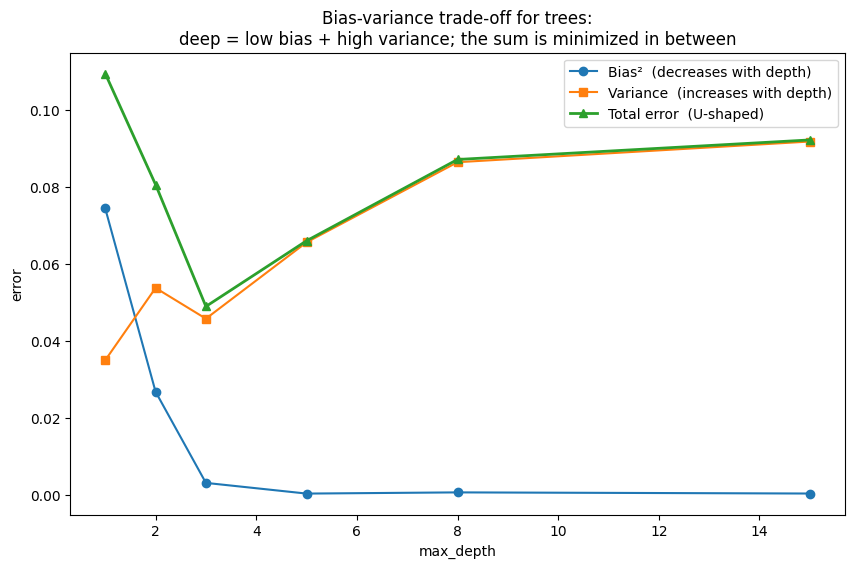

depth  1:  bias²=0.0745   variance=0.0351   total=0.1096
depth  2:  bias²=0.0269   variance=0.0539   total=0.0807
depth  3:  bias²=0.0032   variance=0.0459   total=0.0490
depth  5:  bias²=0.0004   variance=0.0657   total=0.0661
depth  8:  bias²=0.0007   variance=0.0865   total=0.0873
depth 15:  bias²=0.0004   variance=0.0919   total=0.0923


In [300]:
# Cell 3 — Empirical bias-variance decomposition vs tree depth (regression)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# True function we're trying to learn; we'll draw many noisy training sets from it
def true_f(x):
    return np.sin(2 * np.pi * x)

rng = np.random.RandomState(0)
x_test = np.linspace(0, 1, 200).reshape(-1, 1)
f_test = true_f(x_test).ravel()

n_sets, n_train, noise = 200, 60, 0.3
depths = [1, 2, 3, 5, 8, 15]
bias2, variance, total = [], [], []

for d in depths:
    preds = np.zeros((n_sets, len(x_test)))
    for s in range(n_sets):
        # a fresh noisy training set each time
        x_tr = rng.rand(n_train, 1)
        y_tr = true_f(x_tr).ravel() + rng.normal(0, noise, n_train)
        model = DecisionTreeRegressor(max_depth=d, random_state=s).fit(x_tr, y_tr)
        preds[s] = model.predict(x_test)

    mean_pred = preds.mean(axis=0)
    bias2.append(np.mean((mean_pred - f_test)**2))      # avg prediction vs truth
    variance.append(np.mean(preds.var(axis=0)))         # spread of predictions
    total.append(np.mean((preds - f_test)**2))          # actual expected error

plt.figure(figsize=(10, 6))
plt.plot(depths, bias2,    "o-", label="Bias²  (decreases with depth)")
plt.plot(depths, variance, "s-", label="Variance  (increases with depth)")
plt.plot(depths, total,    "^-", lw=2, label="Total error  (U-shaped)")
plt.xlabel("max_depth"); plt.ylabel("error")
plt.title("Bias-variance trade-off for trees:\n"
          "deep = low bias + high variance; the sum is minimized in between")
plt.legend(); plt.show()

for d, b, v, t in zip(depths, bias2, variance, total):
    print(f"depth {d:2d}:  bias²={b:.4f}   variance={v:.4f}   total={t:.4f}")
# Watch bias² fall and variance rise as depth grows — total error bottoms out in the middle.

# Decision Trees Part 5: Controlling Complexity

## Goal
Part 4 showed that an unrestricted tree grows until it memorizes the data — low bias, ruinous variance.
This part covers the levers that **stop that runaway growth** and slide the tree back toward the sweet spot of the bias–variance curve.
There are two philosophies: **pre-pruning** (limit growth while building) and **post-pruning** (build fully, then cut back). Knowing which knob does what — and their failure modes — is what lets you tune a tree deliberately instead of by trial and error.

---

## The Pre-Pruning Hyperparameters
These all impose a **stopping condition** during the recursive split search from Part 3. A node refuses to split (becomes a leaf) if any constraint is violated.

**`max_depth`** — hard cap on tree height.
The bluntest, most-used knob. Directly limits how many times space can be cut, so it directly limits the number of boxes ($\le 2^{\text{depth}}$ leaves).

**`min_samples_split`** — a node needs at least this many samples to be *eligible* to split.
Stops the tree from splitting nodes that are already small (and therefore noisy).

**`min_samples_leaf`** — every resulting **leaf** must hold at least this many samples.
Subtly different from `min_samples_split`: it constrains the *children*, not the parent. A split is rejected if it would create any leaf below the threshold. This is the most reliable guard against tiny "one-point" boxes — it directly attacks the cause of high variance.

**`min_impurity_decrease`** — a split happens only if it reduces impurity by at least this much.
This is a direct **value-of-the-split** test: it's the $\Delta I$ from Part 3 with a minimum bar. Splits that barely help are rejected as probably-noise.

**`max_leaf_nodes`** — cap the total number of leaves (boxes).
Grows the tree **best-first** (expanding the splits with highest impurity decrease first) until the budget is hit, rather than depth-first. A more global complexity cap than `max_depth`.

```text
max_depth            -> how TALL the tree can get
min_samples_split    -> minimum size to even ATTEMPT a split (constrains parent)
min_samples_leaf     -> minimum size of each resulting box   (constrains children)
min_impurity_decrease-> a split must be WORTH it (ΔI ≥ threshold)
max_leaf_nodes       -> total number of boxes (global budget)
```

---

## Pre-Pruning (early stopping)
**Stop growing before the tree is fully grown.** All five hyperparameters above are pre-pruning — they short-circuit the recursion.

- **Pro:** fast (you never build the huge tree), simple to tune.
- **Con — the horizon problem:** it's *greedy and short-sighted*. A split that looks useless *right now* (small $\Delta I$) might enable a highly valuable split one level deeper. Pre-pruning kills that branch before the payoff appears. You can stop too early and leave signal on the table.

---

## Post-Pruning (grow then cut back)
**Grow the tree fully (or nearly), then remove branches that don't earn their keep**, judged against a validation set or a complexity penalty.

- **Pro:** sees the whole tree before deciding, so it sidesteps the horizon problem — it can keep a "weak" split that led to strong splits below.
- **Con:** more expensive (you build the big tree first).

The principled version is **cost-complexity pruning (CART)**, which is Part 6 — so here we just establish *that* post-pruning exists and *why* it can beat pre-pruning, then preview the `ccp_alpha` knob.

```text
pre-pruning  -> decide while building  -> cheap, but can stop too early (greedy)
post-pruning -> build, then trim back  -> costlier, but more global / accurate
```

---

## How These Interact With Bias–Variance
Every one of these knobs moves the tree **left** on the Part-4 curve — toward more bias, less variance:

- Too loose (deep, tiny leaves) → overfit (high variance).
- Too tight (shallow, huge leaves) → underfit (high bias).
- The right setting is found by **validation** — tune the knob, watch the validation score, pick the peak. (Chronological split for your time-series work, so the validation estimate is honest.)

---

## Main Idea
Complexity control = deliberately stopping the tree short of memorization.

```text
pre-pruning  : max_depth, min_samples_split, min_samples_leaf,
               min_impurity_decrease, max_leaf_nodes  (stop early)
post-pruning : grow fully, then cut weak branches     (Part 6: ccp_alpha)
```

- `min_samples_leaf` and `max_depth` are your everyday workhorses.
- Pre-pruning is cheap but greedy (horizon problem); post-pruning is costlier but more global.
- Whichever you use, **validation picks the setting** — you're choosing where to sit on the bias–variance trade-off.

## Shows each pre-pruning knob's effect on tree size and the train/validation gap, side by side:

In [301]:
# Cell 1 — Each pre-pruning knob: its effect on tree size and the train/val gap
import numpy as np
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=1500, n_features=20, n_informative=6,
                           n_redundant=4, flip_y=0.08, random_state=0)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.4, random_state=0)

# Baseline: a fully grown (unconstrained) tree memorizes the training set
base = DecisionTreeClassifier(random_state=0).fit(X_tr, y_tr)
print(f"{'setting':<34}{'leaves':>7}{'depth':>7}{'train':>8}{'val':>8}{'gap':>8}")
print("-" * 72)
def report(name, clf):
    tr, va = clf.score(X_tr, y_tr), clf.score(X_val, y_val)
    print(f"{name:<34}{clf.get_n_leaves():>7}{clf.get_depth():>7}"
          f"{tr:>8.3f}{va:>8.3f}{tr-va:>8.3f}")
report("UNCONSTRAINED (overfit)", base)

# Now apply each knob in isolation so you can see what each one does
configs = [
    ("max_depth=4",                 dict(max_depth=4)),
    ("min_samples_split=50",        dict(min_samples_split=50)),
    ("min_samples_leaf=30",         dict(min_samples_leaf=30)),
    ("min_impurity_decrease=0.005", dict(min_impurity_decrease=0.005)),
    ("max_leaf_nodes=16",           dict(max_leaf_nodes=16)),
]
for name, kw in configs:
    clf = DecisionTreeClassifier(random_state=0, **kw).fit(X_tr, y_tr)
    report(name, clf)

# Every constrained tree has FEWER leaves and a SMALLER train-val gap than the
# unconstrained one. Smaller gap = less variance = the knob is doing its job.

setting                            leaves  depth   train     val     gap
------------------------------------------------------------------------
UNCONSTRAINED (overfit)                98     13   1.000   0.777   0.223
max_depth=4                            14      4   0.840   0.760   0.080
min_samples_split=50                   35     12   0.880   0.777   0.103
min_samples_leaf=30                    22      7   0.853   0.768   0.085
min_impurity_decrease=0.005            15      9   0.883   0.783   0.100
max_leaf_nodes=16                      16      9   0.887   0.783   0.103


## Distinguishes the two confusingly, similar knobs

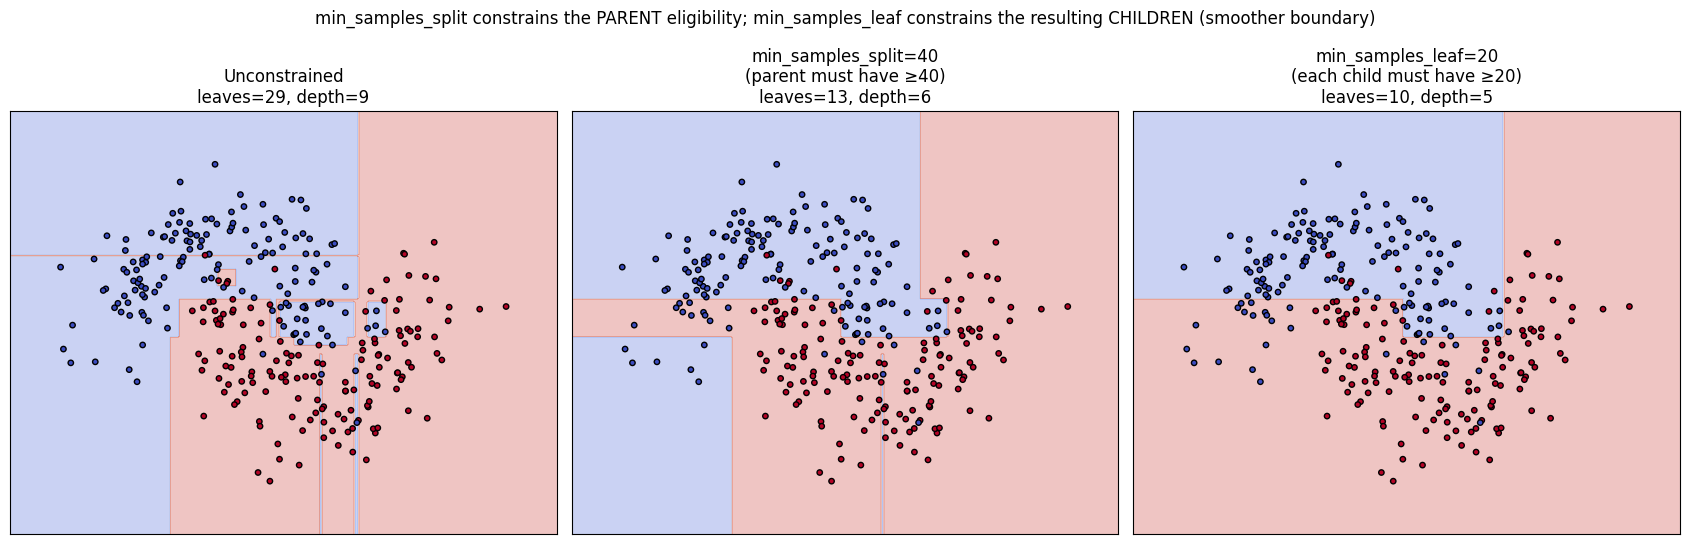

In [302]:
# Cell 2 — min_samples_split vs min_samples_leaf: parent rule vs child rule
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

X, y = make_moons(n_samples=300, noise=0.3, random_state=0)
x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
grid = np.c_[xx.ravel(), yy.ravel()]

settings = [
    ("Unconstrained", dict()),
    ("min_samples_split=40\n(parent must have ≥40)", dict(min_samples_split=40)),
    ("min_samples_leaf=20\n(each child must have ≥20)", dict(min_samples_leaf=20)),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, (name, kw) in zip(axes, settings):
    clf = DecisionTreeClassifier(random_state=0, **kw).fit(X, y)
    Z = clf.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k", s=15)
    ax.set_title(f"{name}\nleaves={clf.get_n_leaves()}, depth={clf.get_depth()}")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("min_samples_split constrains the PARENT eligibility; "
             "min_samples_leaf constrains the resulting CHILDREN (smoother boundary)")
plt.tight_layout(); plt.show()

# min_samples_leaf tends to give the cleaner boundary because it directly forbids
# the tiny one-or-two-point boxes that cause the jagged overfitting from Part 4.

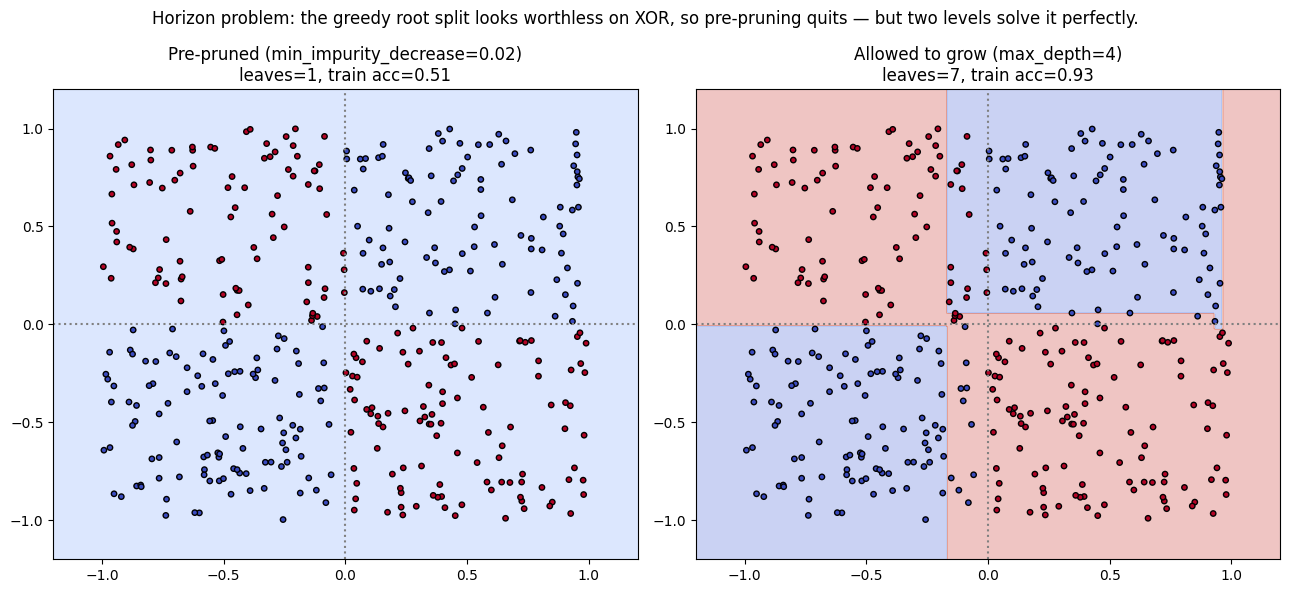

pre-pruned train accuracy: 0.512  (stopped too early)
grown     train accuracy: 0.932  (found the structure)


In [303]:
# Cell 3 — The horizon problem: why pre-pruning can stop too early (XOR)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# XOR pattern: NO single axis-aligned split improves purity at the root,
# but TWO levels of splitting separate the classes perfectly.
rng = np.random.RandomState(0)
X = rng.uniform(-1, 1, size=(400, 2))
y = ((X[:, 0] > 0) ^ (X[:, 1] > 0)).astype(int)   # checkerboard / XOR

x_min, x_max, y_min, y_max = -1.2, 1.2, -1.2, 1.2
xx, yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Aggressive pre-pruning: require each split to clear a min impurity decrease.
# The root split barely helps on XOR, so this tree gives up almost immediately.
pre = DecisionTreeClassifier(min_impurity_decrease=0.02, random_state=0).fit(X, y)
# No early stop: the tree pushes past the unhelpful first split to the payoff below.
full = DecisionTreeClassifier(max_depth=4, random_state=0).fit(X, y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
for ax, clf, name in [(ax1, pre, "Pre-pruned (min_impurity_decrease=0.02)"),
                      (ax2, full, "Allowed to grow (max_depth=4)")]:
    Z = clf.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k", s=15)
    ax.set_title(f"{name}\nleaves={clf.get_n_leaves()}, "
                 f"train acc={clf.score(X,y):.2f}")
    ax.axhline(0, color="gray", ls=":"); ax.axvline(0, color="gray", ls=":")
plt.suptitle("Horizon problem: the greedy root split looks worthless on XOR, so "
             "pre-pruning quits — but two levels solve it perfectly.")
plt.tight_layout(); plt.show()

print(f"pre-pruned train accuracy: {pre.score(X,y):.3f}  (stopped too early)")
print(f"grown     train accuracy: {full.score(X,y):.3f}  (found the structure)")
# This is the case FOR post-pruning: build the tree, THEN decide what to cut.

## Quick previews -> showing it shrinks a fully grown tree and can match a pre-pruning  


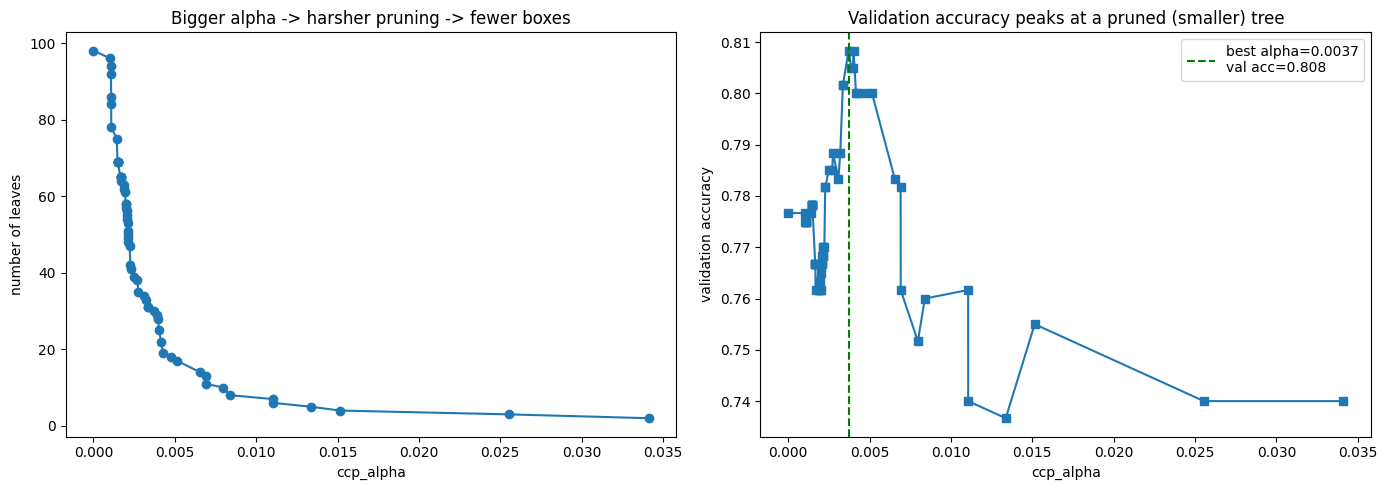

full tree:   98 leaves, val acc=0.777
best pruned: 30 leaves, val acc=0.808


In [304]:
# Cell 4 — Post-pruning preview: grow fully, then cut back with ccp_alpha
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=1500, n_features=20, n_informative=6,
                           n_redundant=4, flip_y=0.08, random_state=0)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.4, random_state=0)

# Grow a full tree, then get the sequence of alphas at which branches get pruned
full = DecisionTreeClassifier(random_state=0).fit(X_tr, y_tr)
path = full.cost_complexity_pruning_path(X_tr, y_tr)
alphas = path.ccp_alphas[:-1]      # drop the last (collapses tree to a single root)

# Train one pruned tree per alpha and track size + validation accuracy
n_leaves, val_acc = [], []
for a in alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=a).fit(X_tr, y_tr)
    n_leaves.append(clf.get_n_leaves())
    val_acc.append(clf.score(X_val, y_val))

best = int(np.argmax(val_acc))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(alphas, n_leaves, "o-"); ax1.set_xlabel("ccp_alpha")
ax1.set_ylabel("number of leaves")
ax1.set_title("Bigger alpha -> harsher pruning -> fewer boxes")

ax2.plot(alphas, val_acc, "s-")
ax2.axvline(alphas[best], color="green", ls="--",
            label=f"best alpha={alphas[best]:.4f}\nval acc={val_acc[best]:.3f}")
ax2.set_xlabel("ccp_alpha"); ax2.set_ylabel("validation accuracy")
ax2.set_title("Validation accuracy peaks at a pruned (smaller) tree")
ax2.legend()
plt.tight_layout(); plt.show()

print(f"full tree:   {full.get_n_leaves()} leaves, val acc={full.score(X_val,y_val):.3f}")
print(f"best pruned: {n_leaves[best]} leaves, val acc={val_acc[best]:.3f}")
# Grew fully, then cut back to a smaller, better-generalizing tree. That's post-pruning —
# and the principled mechanism behind ccp_alpha is exactly what Part 6 covers.